In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.3 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from google.colab import drive
import torch
from sklearn.metrics import roc_curve, auc
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, Dataset

In [ ]:
# ==== Driveマウント ====
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ==== データセットルート ====
BASE_DIR = Path('/content/drive/MyDrive/研究/data/MMU-Iris-Database')
IMG_EXTS = {'.bmp', '.png', '.jpg', '.jpeg'}

# ==== GPU設定 ====
# ※今回の古典的手法(OpenCV)は主にCPUで動作するが、設定は保持
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [ ]:
# === クラス定義 ===
class IrisRecognizer:
    def __init__(self):
        self.norm_height = 64
        self.norm_width = 512

    def preprocess(self, img):
        # gamma = 0.8
        # inv_gamma = 1.0 / gamma
        # table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        # img_gamma = cv2.LUT(img, table)
        # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        # img_clahe = clahe.apply(img_gamma)
        # img_blur = cv2.medianBlur(img_clahe, 5)

        _, bright_mask = cv2.threshold(img, 220, 255, cv2.THRESH_BINARY)
        img_inpaineted = cv2.inpaint(img, bright_mask, 3, cv2.INPAINT_TELEA)
        img_blur = cv2.medianBlur(img_inpaineted, 5)
        return img_blur

    def detect_iris_circles(self, image):
        # 処理用画像
        _, bright_mask = cv2.threshold(image, 220, 255, cv2.THRESH_BINARY)
        img_inpainted = cv2.inpaint(image, bright_mask, 3, cv2.INPAINT_TELEA)
        img_blur = cv2.medianBlur(img_inpainted, 9)

        # 瞳孔検出
        best_pupil = None
        best_circularity = 0
        min_pupil_area = 50
        max_pupil_area = (image.shape[0] * image.shape[1]) // 10

        for thresh in range(10, 90, 5):
            _, binary = cv2.threshold(img_blur, thresh, 255, cv2.THRESH_BINARY_INV)
            contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for cnt in contours:
                area = cv2.contourArea(cnt)
                if area < min_pupil_area or area > max_pupil_area: continue
                perimeter = cv2.arcLength(cnt, True)
                if perimeter == 0: continue
                circularity = 4 * np.pi * (area / (perimeter ** 2))

                if circularity > 0.75 and circularity > best_circularity:
                    best_circularity = circularity
                    (x, y), radius = cv2.minEnclosingCircle(cnt)
                    best_pupil = (int(x), int(y), int(radius))

        if best_pupil is None:
            # 救済措置: Hough変換
            circles = cv2.HoughCircles(img_blur, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
                                     param1=100, param2=15, minRadius=10, maxRadius=50)
            if circles is not None:
                circles = np.uint16(np.around(circles))
                p = circles[0, 0]
                best_pupil = (p[0], p[1], p[2])
            else:
                return None, None

        px, py, pr = best_pupil

        # 虹彩検出
        min_iris_r = int(pr * 1.3)
        max_iris_r = int(pr * 3.0)
        edges = cv2.Canny(img_blur, 50, 150)
        cv2.circle(edges, (px, py), int(pr * 1.2), 0, -1)

        circles_iris = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1, minDist=100,
                                        param1=50, param2=15, minRadius=min_iris_r, maxRadius=max_iris_r)

        best_iris = None
        if circles_iris is not None:
            circles_iris = np.uint16(np.around(circles_iris))
            min_dist = float('inf')

            for c in circles_iris[0, :]:
                ix, iy, ir = c[0], c[1], c[2]

                # floatキャストによるオーバーフロー回避
                dist = np.sqrt(float(px - ix)**2 + float(py - iy)**2)

                if dist < pr * 0.3:
                    if dist < min_dist:
                        min_dist = dist
                        best_iris = (ix, iy, ir)

        if best_iris is None:
             best_iris = (px, py, int(pr * 2.5))

        return best_pupil, best_iris

    def normalize_iris(self, img, pupil, iris):
        xp, yp, rp = pupil
        xi, yi, ri = iris
        polar_img = np.zeros((self.norm_height, self.norm_width), dtype=np.uint8)
        theta = np.linspace(0, 2 * np.pi, self.norm_width)

        for i in range(self.norm_width):
            t = theta[i]
            cos_t = np.cos(t)
            sin_t = np.sin(t)
            x_p_t = xp + rp * cos_t
            y_p_t = yp + rp * sin_t
            x_i_t = xi + ri * cos_t
            y_i_t = yi + ri * sin_t

            for j in range(self.norm_height):
                r = j / self.norm_height
                x = int((1 - r) * x_p_t + r * x_i_t)
                y = int((1 - r) * y_p_t + r * y_i_t) # y_i_t (Corrected)

                if 0 <= y < img.shape[0] and 0 <= x < img.shape[1]:
                    polar_img[j, i] = img[y, x]
        return polar_img

    # def extract_features(self, norm_img):
    #     norm_img_eq = cv2.equalizeHist(norm_img)
    #     ksize, sigma, theta, lambd, gamma = 31, 3.0, 0, 8.0, 0.5

    #     # 実部と虚部のカーネル作成
    #     kernel_real = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, 0, ktype=cv2.CV_32F)
    #     kernel_imag = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, np.pi/2, ktype=cv2.CV_32F)

    #     # フィルタリング
    #     f_real = cv2.filter2D(norm_img, cv2.CV_32F, kernel_real)
    #     f_imag = cv2.filter2D(norm_img, cv2.CV_32F, kernel_imag)

    #     # 量子化
    #     code_real = np.where(f_real > 0, 1, 0).astype(np.int8)
    #     code_imag = np.where(f_imag > 0, 1, 0).astype(np.int8)

    #     # マスク作成（少し緩めて情報を確保）
    #     mask = np.zeros_like(code_real, dtype=np.int8)
    #     w = self.norm_width
    #     mask[:, :int(w/5)] = 1       # 左右端をマスク（少し狭めた）
    #     mask[:, int(w*4/5):] = 1
    #     mask[50:, :] = 0             # 上から50pxまで使う（以前は40pxで切っていた）

    #     intensity_mask = np.where((norm_img > 20) & (norm_img < 240), 1, 0).astype(np.int8)
    #     final_mask = mask & intensity_mask

    #     # ★ここが重要：実部と虚部を結合して返す
    #     iris_code = np.concatenate([code_real, code_imag], axis=0)
    #     iris_mask = np.concatenate([final_mask, final_mask], axis=0)

    #     return iris_code, None, iris_mask

    def extract_features(self, norm_img):
        # --- 変更点1：CLAHEをここでかける ---
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        norm_img_enhanced = clahe.apply(norm_img) # これをGaborに入力

        ksize, sigma, theta, lambd, gamma = 31, 3.0, 0, 8.0, 0.5

        # フィルタリング (入力画像を enhanced 版に変更)
        kernel_real = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, 0, ktype=cv2.CV_32F)
        kernel_imag = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, np.pi/2, ktype=cv2.CV_32F)

        f_real = cv2.filter2D(norm_img_enhanced, cv2.CV_32F, kernel_real)
        f_imag = cv2.filter2D(norm_img_enhanced, cv2.CV_32F, kernel_imag)

        # 量子化
        code_real = np.where(f_real > 0, 1, 0).astype(np.int8)
        code_imag = np.where(f_imag > 0, 1, 0).astype(np.int8)

        # --- 変更点2：マスク範囲の適正化 ---
        # 1 = 有効, 0 = 無効
        mask = np.zeros_like(code_real, dtype=np.int8)
        w = self.norm_width

        # 角度0度付近（右側）を有効化
        mask[:, :int(w/6)] = 1
        mask[:, int(w*5/6):] = 1

        # ★追加：角度180度付近（左側）も有効化
        # 中央(w/2)を中心に左右へ広げる
        center = int(w/2)
        span = int(w/6)
        mask[:, center - span : center + span] = 1

        # 上下のフチ（ノイズが多い部分）をカット
        mask[50:, :] = 0
        mask[:5, :] = 0  # 上端も少し切ると安定します

        # 輝度によるマスク（真っ黒・真っ白すぎる場所は無視）
        intensity_mask = np.where((norm_img > 20) & (norm_img < 240), 1, 0).astype(np.int8)

        final_mask = mask & intensity_mask

        # 実部と虚部を結合
        iris_code = np.concatenate([code_real, code_imag], axis=0)
        # マスクも同じサイズに拡張が必要
        iris_mask = np.concatenate([final_mask, final_mask], axis=0)

        return iris_code, None, iris_mask

    # def compute_hamming_distance(self, code1, code2, mask1, mask2, shift_range=8):
    #     combined_mask = np.logical_and(mask1, mask2)
    #     if np.sum(combined_mask) == 0: return 1.0
    #     min_score = 1.0
    #     for shift in range(-shift_range, shift_range + 1):
    #         code1_shifted = np.roll(code1, shift, axis=1)
    #         mask1_shifted = np.roll(mask1, shift, axis=1)
    #         current_mask = np.logical_and(mask1_shifted, mask2)
    #         total_bits = np.sum(current_mask)
    #         if total_bits == 0: continue
    #         xor_result = np.logical_xor(code1_shifted, code2)
    #         mismatch_count = np.sum(np.logical_and(xor_result, current_mask))
    #         score = mismatch_count / total_bits
    #         if score < min_score: min_score = score
    #     return min_score


    def compute_hamming_distance(self, code1, code2, mask1, mask2, shift_range=8):
        # どちらかが完全にマスクされているなら、不一致(1.0)を返す
        if np.sum(mask1) == 0 or np.sum(mask2) == 0:
            return 1.0

        min_score = 1.0
        for shift in range(-shift_range, shift_range + 1):
            code1_shifted = np.roll(code1, shift, axis=1)
            mask1_shifted = np.roll(mask1, shift, axis=1)

            # 両方が「有効(1)」であるビットだけを比較対象にする
            valid_mask = np.logical_and(mask1_shifted, mask2)
            total_valid_bits = np.sum(valid_mask)

            if total_valid_bits < 100: # 有効ビットが少なすぎる場合は信頼できないのでスキップ
                continue

            xor_result = np.logical_xor(code1_shifted, code2)
            # 有効な場所での不一致数
            mismatch_count = np.sum(np.logical_and(xor_result, valid_mask))

            score = mismatch_count / total_valid_bits
            if score < min_score:
                min_score = score

        return min_score

In [ ]:
# # ==== デバッグ用可視化コード ====
# def visualize_processing(img_path, recognizer):
#     img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
#     if img is None:
#         print("Image not found")
#         return

#     # 1. 前処理
#     img_pre = recognizer.preprocess(img)

#     # 2. 円検出
#     pupil, iris = recognizer.detect_iris_circles(img_pre)

#     # 描画用画像（カラー変換）
#     debug_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

#     norm_img = None
#     if pupil is not None and iris is not None:
#         # 外円（虹彩）: 青
#         cv2.circle(debug_img, (iris[0], iris[1]), iris[2], (255, 0, 0), 2)
#         # 内円（瞳孔）: 赤
#         cv2.circle(debug_img, (pupil[0], pupil[1]), pupil[2], (0, 0, 255), 2)

#         # 3. 正規化画像の生成
#         norm_img = recognizer.normalize_iris(img_pre, pupil, iris)
#     else:
#         print("Circle detection failed!")

#     # 表示
#     plt.figure(figsize=(15, 5))

#     # 元画像 + 検出円
#     plt.subplot(1, 3, 1)
#     plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
#     plt.title("Detected Circles (Red:Pupil, Blue:Iris)")
#     plt.axis('off')

#     # 前処理後画像
#     plt.subplot(1, 3, 2)
#     plt.imshow(img_pre, cmap='gray')
#     plt.title("Preprocessed Image")
#     plt.axis('off')

#     # 正規化画像 (展開図)
#     plt.subplot(1, 3, 3)
#     if norm_img is not None:
#         plt.imshow(norm_img, cmap='gray')
#         plt.title("Normalized Iris (Rubber Sheet)")
#     else:
#         plt.text(0.5, 0.5, "Detection Failed", ha='center')
#     plt.axis('off')

#     plt.show()

# # ランダムに数枚選んで可視化
# import random
# # エラー修正: debug_img ではなく image_paths からサンプリングします。
# # image_paths は、このセルが実行される前に定義されている必要があります。
# random_paths = random.sample(image_paths, 3) # 3枚ピックアップ

# print("=== Visualizing Random Samples ===")
# for p in random_paths:
#     print(f"File: {p}")
#     visualize_processing(p, recognizer)


In [ ]:
# ==== 画像収集 ====
def list_all_images(base_dir: Path):
    paths = []
    for p in base_dir.rglob('*'):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            paths.append(p)
    return sorted(paths)

def get_subject_id(path: Path):
    parts = Path(path).parts
    subject_num = parts[-3]
    eye_side = parts[-2]

    return f"{subject_num}_{eye_side}"

# インスタンス化
recognizer = IrisRecognizer()
image_paths = list_all_images(BASE_DIR)

print(f"Total images found: {len(image_paths)}")

# ==== 特徴量データベース作成 ====
# 形式: [{"id": subject_id, "path": path, "code_real": cr, "mask": m}, ...]
database = []

print("Processing images...")
for p in tqdm(image_paths):
    # 画像読み込み
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue

    # 1. 前処理
    img_pre = recognizer.preprocess(img)

    # 2. 円検出
    # detect_iris_circlesは(pupil, iris)を返す
    pupil, iris = recognizer.detect_iris_circles(img_pre)

    if pupil is None or iris is None:
        # 検出失敗時はスキップ
        continue

    # 3. 正規化
    norm_img = recognizer.normalize_iris(img_pre, pupil, iris)

    # 4. 特徴抽出 (Gabor) - code_real, code_imag, final_mask を返す
    code_real, code_imag, final_mask = recognizer.extract_features(norm_img)

    # DBに追加
    subj_id = get_subject_id(p)
    database.append({
        "id": subj_id,
        "path": str(p),
        "code_real": code_real, # code_realを格納
        "code_imag": code_imag, # 必要であればcode_imagも格納（今回は使わないが保持）
        "mask": final_mask      # マスクを格納
    })

print(f"Successfully processed: {len(database)} / {len(image_paths)}")

Total images found: 450
Processing images...


  0%|          | 0/450 [00:00<?, ?it/s]/tmp/ipython-input-996667557.py:80: RuntimeWarning: overflow encountered in scalar subtract
  dist = np.sqrt(float(px - ix)**2 + float(py - iy)**2)
100%|██████████| 450/450 [08:41<00:00,  1.16s/it]

Successfully processed: 450 / 450


Visualizing Random Samples...


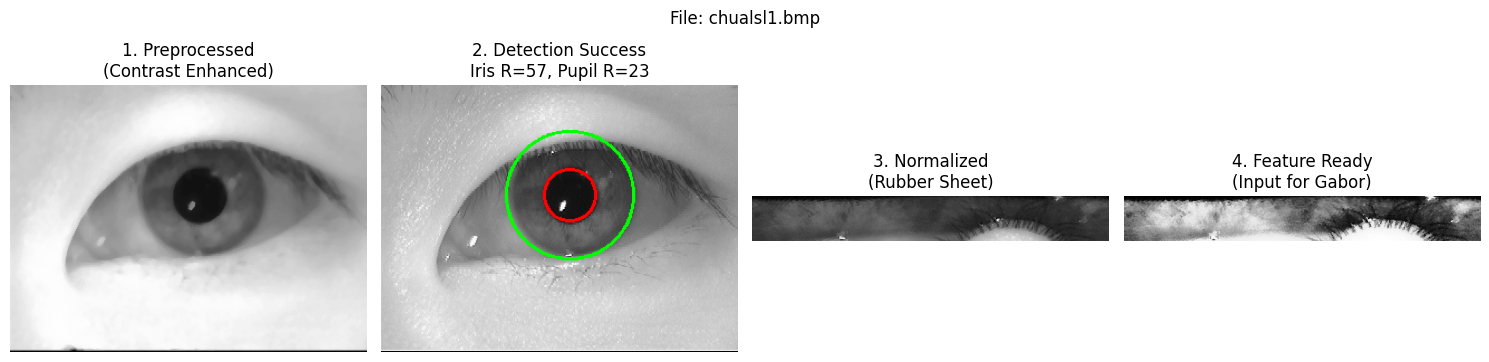

/tmp/ipython-input-996667557.py:80: RuntimeWarning: overflow encountered in scalar subtract
  dist = np.sqrt(float(px - ix)**2 + float(py - iy)**2)


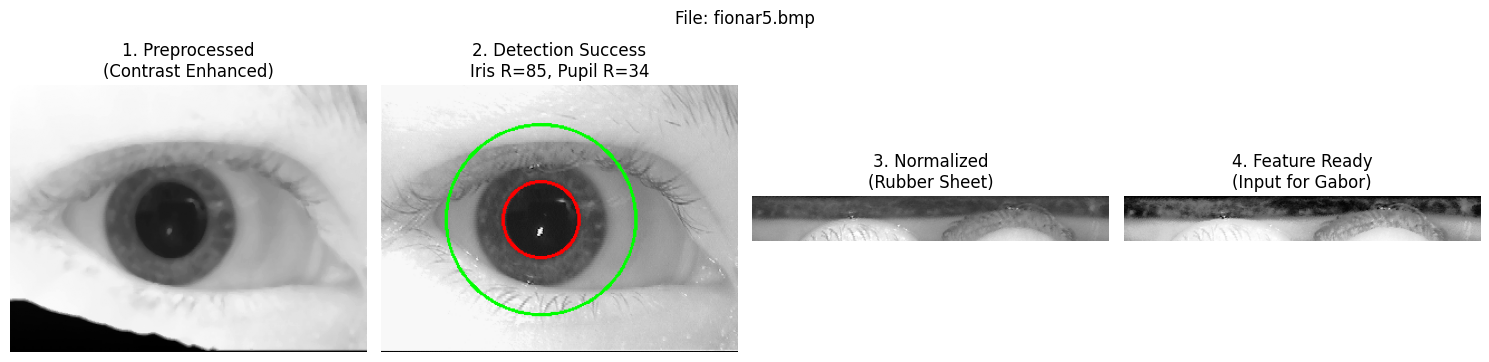

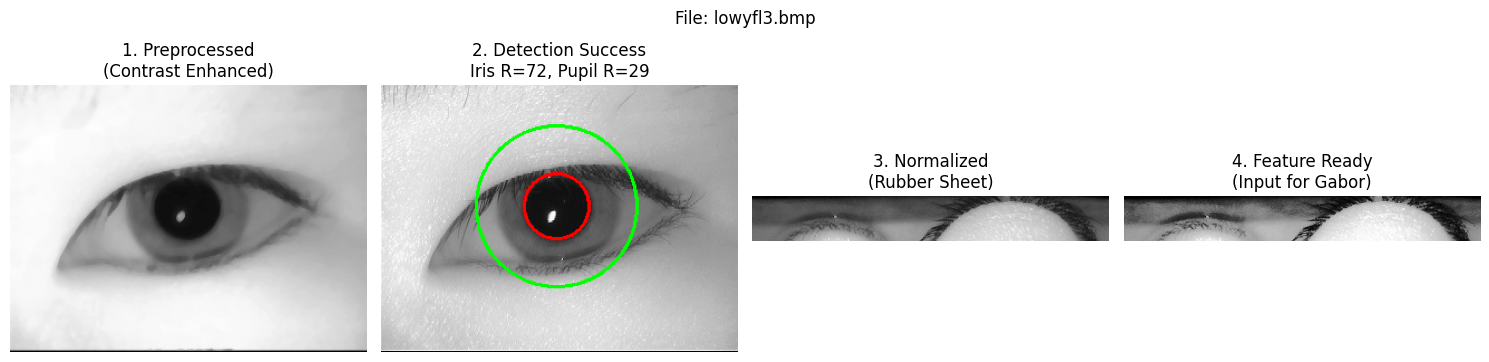

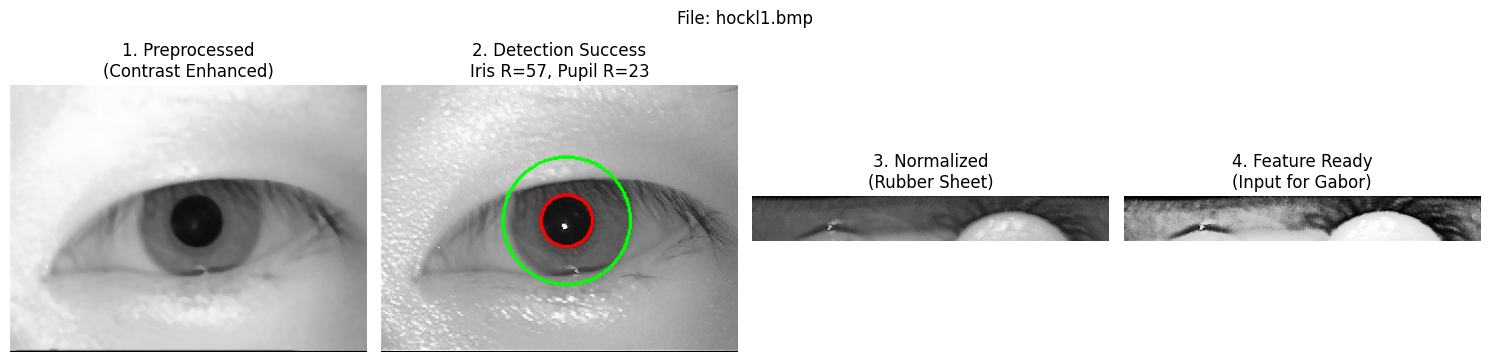

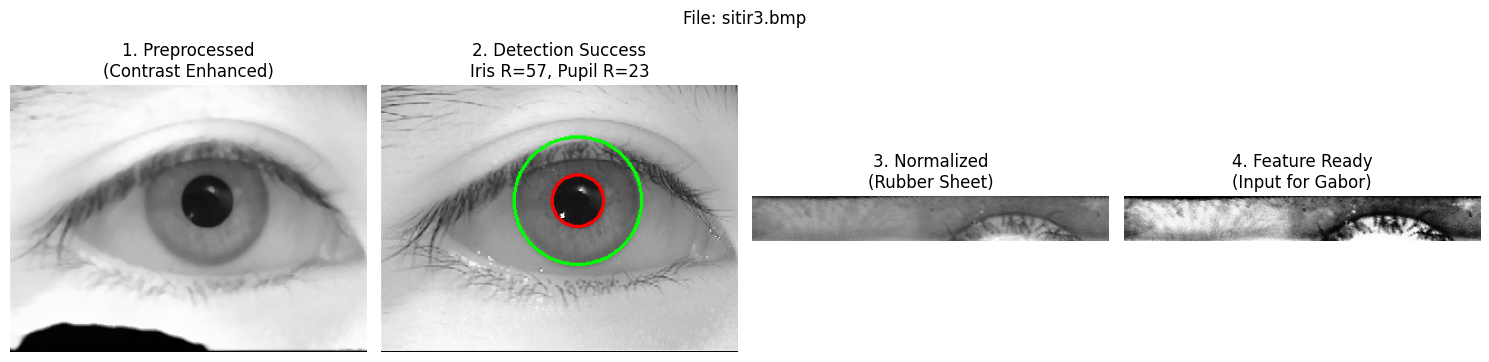

In [ ]:
import random
import matplotlib.pyplot as plt

def debug_iris_pipeline(recognizer, database_or_paths, num_samples=3):
    """
    指定された画像に対して、処理の各段階（前処理・検出・正規化）を可視化します。

    Args:
        recognizer: IrisRecognizerのインスタンス
        database_or_paths: 画像パスのリスト、またはdatabaseリスト
        num_samples: 表示するサンプル数
    """

    # パスリストの抽出
    if len(database_or_paths) > 0 and isinstance(database_or_paths[0], dict):
        # database辞書が渡された場合
        paths = [d['image_path'] for d in database_or_paths]
    else:
        # パスのリストが渡された場合
        paths = database_or_paths

    # ランダムにサンプリング（データ数が少ない場合は全件）
    sample_paths = random.sample(paths, min(len(paths), num_samples))

    for img_path in sample_paths:
        # 画像読み込み
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Error: Cannot load {img_path}")
            continue

        plt.figure(figsize=(15, 4))
        plt.suptitle(f"File: {os.path.basename(img_path)}", fontsize=12)

        # --- 1. 前処理後の画像 (Preprocessing) ---
        # クラス内のpreprocessメソッドが返す画像を確認
        # ※detect_iris_circles内部でも同様の処理が行われます
        img_pre = recognizer.preprocess(img)

        plt.subplot(1, 4, 1)
        plt.imshow(img_pre, cmap='gray')
        plt.title("1. Preprocessed\n(Contrast Enhanced)")
        plt.axis('off')

        # --- 2. 円検出 (Circle Detection) ---
        pupil, iris = recognizer.detect_iris_circles(img)

        img_circles = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        plt.subplot(1, 4, 2)
        if pupil is not None and iris is not None:
            # 虹彩（外円）を緑で描画
            xi, yi, ri = iris
            cv2.circle(img_circles, (xi, yi), ri, (0, 255, 0), 2)
            # 瞳孔（内円）を赤で描画
            xp, yp, rp = pupil
            cv2.circle(img_circles, (xp, yp), rp, (255, 0, 0), 2)

            plt.imshow(img_circles)
            plt.title(f"2. Detection Success\nIris R={ri}, Pupil R={rp}")
        else:
            # 失敗時は赤枠などを表示
            plt.imshow(img_circles)
            plt.title("2. Detection FAILED", color='red')
        plt.axis('off')

        # --- 3. 正規化 (Normalization) ---
        plt.subplot(1, 4, 3)
        if pupil is not None and iris is not None:
            try:
                norm_img = recognizer.normalize_iris(img, pupil, iris)
                plt.imshow(norm_img, cmap='gray')
                plt.title("3. Normalized\n(Rubber Sheet)")
            except Exception as e:
                plt.text(0.5, 0.5, "Norm Error", ha='center')
                plt.title("Normalization Error")
        else:
            plt.text(0.5, 0.5, "No Data", ha='center')
            plt.title("Skipped")
        plt.axis('off')

        # --- 4. 特徴抽出 (Gabor Filter Response) ---
        # 実際にコード化される直前のフィルタ応答を見る（オプション）
        plt.subplot(1, 4, 4)
        if pupil is not None and iris is not None:
            # 簡易的に特徴抽出の最初のステップを表示
            # ※ extract_featuresの戻り値が変わったため、可視化用に別途処理
            norm_eq = cv2.equalizeHist(norm_img)
            plt.imshow(norm_eq, cmap='gray')
            plt.title("4. Feature Ready\n(Input for Gabor)")
        else:
            plt.text(0.5, 0.5, "No Data", ha='center')
            plt.title("Skipped")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# === 実行例 ===
# databaseを作成する前の「画像パスリスト」または作成後の「database」を渡してください
# 例: image_paths という変数がノートブック上にあるはずです
print("Visualizing Random Samples...")
debug_iris_pipeline(recognizer, image_paths, num_samples=5)

Calculating Hamming Distances with Optimized Shift Range (8)...
Genuine pairs: 900
Imposter pairs: 100125
Equal Error Rate (EER): 0.0911


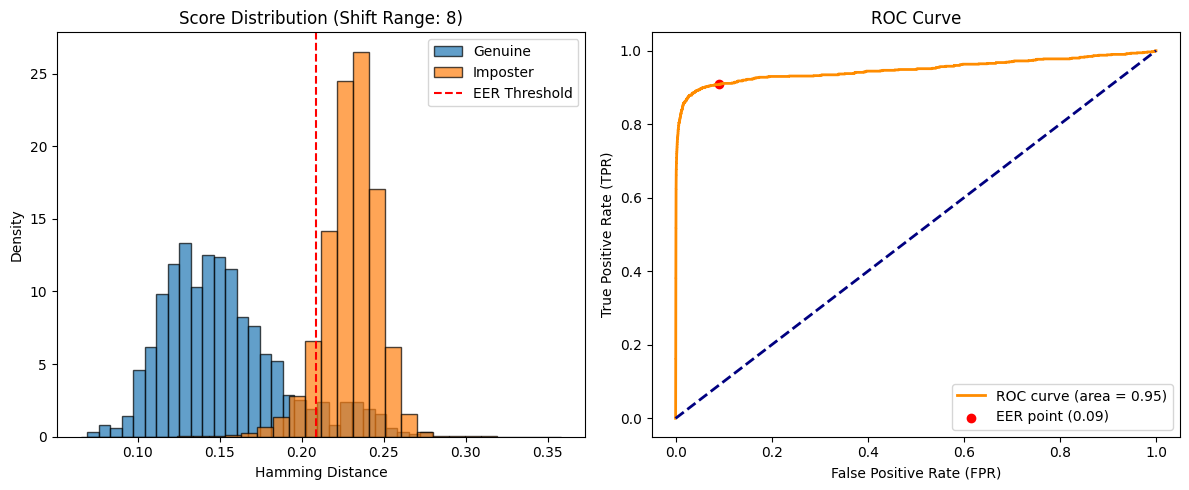

In [ ]:
# ==== マッチング実験 ====
genuine_scores = []
imposter_scores = []

num_data = len(database)

print("Calculating Hamming Distances with Optimized Shift Range (8)...")

for i in range(num_data):
    for j in range(i + 1, num_data):
        # --- 変更点：databaseから'code_real'と'mask'を取得 ---
        # code_realを虹彩コードとして使用
        code1 = database[i]["code_real"]
        mask1 = database[i]["mask"]
        id1   = database[i]["id"]

        code2 = database[j]["code_real"]
        mask2 = database[j]["mask"]
        id2   = database[j]["id"]

        # --- 変更点：探索範囲を shift_range=8 に絞る ---
        dist = recognizer.compute_hamming_distance(code1, code2, mask1, mask2, shift_range=8)

        if id1 == id2:
            genuine_scores.append(dist)
        else:
            imposter_scores.append(dist)

genuine_scores = np.array(genuine_scores)
imposter_scores = np.array(imposter_scores)

print(f"Genuine pairs: {len(genuine_scores)}")
print(f"Imposter pairs: {len(imposter_scores)}")

# ==== EER 計算 ====
labels = [1] * len(genuine_scores) + [0] * len(imposter_scores)
scores = np.concatenate([genuine_scores, imposter_scores])

# スコアが低いほどGenuineなため、-1倍してpos_label=1でROCを描く
fpr, tpr, thresholds = roc_curve(labels, -scores, pos_label=1)

# EERを求める
fnr = 1 - tpr
eer_threshold_idx = np.nanargmin(np.absolute(fnr - fpr))
eer = fpr[eer_threshold_idx]

print(f"Equal Error Rate (EER): {eer:.4f}")

# ==== 結果の可視化 ====
plt.figure(figsize=(12, 5))

# ヒストグラム：オレンジ色（他人）の山が 0.5 付近に集まるか確認
plt.subplot(1, 2, 1)
plt.hist(genuine_scores, bins=30, alpha=0.7, label='Genuine', density=True, edgecolor='black')
plt.hist(imposter_scores, bins=30, alpha=0.7, label='Imposter', density=True, edgecolor='black')
plt.axvline(x=-thresholds[eer_threshold_idx], color='r', linestyle='--', label=f'EER Threshold')
plt.xlabel('Hamming Distance')
plt.ylabel('Density')
plt.title('Score Distribution (Shift Range: 8)')
plt.legend()

# ROC曲線：左上の角への張り付き具合を確認
roc_auc = auc(fpr, tpr)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[eer_threshold_idx], tpr[eer_threshold_idx], color='red', label=f'EER point ({eer:.2f})')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# 最初の10件のIDを表示して確認
for i in range(min(10, len(database))):
    print(f"Path: {database[i]['path']} -> Subject ID: {database[i]['id']}")

Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/left/aeval1.bmp -> Subject ID: 1_left
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/left/aeval2.bmp -> Subject ID: 1_left
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/left/aeval3.bmp -> Subject ID: 1_left
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/left/aeval4.bmp -> Subject ID: 1_left
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/left/aeval5.bmp -> Subject ID: 1_left
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/right/aevar1.bmp -> Subject ID: 1_right
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/right/aevar2.bmp -> Subject ID: 1_right
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/right/aevar3.bmp -> Subject ID: 1_right
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/right/aevar4.bmp -> Subject ID: 1_right
Path: /content/drive/MyDrive/研究/data/MMU-Iris-Database/1/right/aevar5.bmp -> Subject ID: 1_right


In [ ]:
# 本人ペアの距離だけを確認
if len(genuine_scores) > 0:
    print(f"本人ペアの平均距離: {np.mean(genuine_scores):.4f}")
    print(f"本人ペアの最小距離: {np.min(genuine_scores):.4f}")
    print(f"本人ペアの最大距離: {np.max(genuine_scores):.4f}")

本人ペアの平均距離: 0.1515
本人ペアの最小距離: 0.0691
本人ペアの最大距離: 0.2794
